# LLM confidence calibration on tweet irony detection — direct-probability prompt

This notebook is a variant of [`irony_sonnet_100.ipynb`](irony_sonnet_100.ipynb) that
asks the model for **one number per example: `P(text is ironic)`**, rather than
asking for a label and a separate confidence-in-label as the other Anthropic notebooks
do.

The implied label is derived in the parser (`label = 1 if P >= 0.5 else 0`), and the
confidence in that label is `max(P, 1-P)` — bounded `[0.5, 1.0]` by construction. After
that transform the signal slots into the existing pipeline unchanged: same ECE,
reliability diagram, AUROC, and histograms.

**Why a separate notebook for this.** It's a different elicitation: the verbalized
prompt asks "how sure are you about your answer", which conflates the answer with the
self-assessment. This prompt asks "what's the probability of class 1", which is the
raw quantity that a calibrated model should track frequencies of. The comparison is
worth doing on the same model and dataset.

The mapping is lossless — `P(ironic) = conf if pred == 1 else 1 - conf` — so the raw
probability can always be recovered from the cached CSV.

## Setup

Requires an `ANTHROPIC_API_KEY` environment variable. Shared utilities (data loading,
prompt templates, run loop, ECE / AUROC math, plots) live in [`calib.py`](calib.py) —
this notebook handles model selection and result presentation.

Install dependencies if needed:

In [1]:
# !pip install datasets anthropic scikit-learn numpy matplotlib

In [2]:
import os

import numpy as np
from anthropic import Anthropic

import calib

# config — what's specific to this run
MODEL = "claude-sonnet-4-6"  # same model as the verbal-confidence sonnet notebook;
                             # only the elicitation prompt changes
N_SAMPLES = 4601
N_BINS = 30
SCALE = 100            # probability top end (model asked for integer 0-100)
SEED = 0
RESULTS_CSV = "data/irony_sonnet_prob.csv"

assert os.environ.get("ANTHROPIC_API_KEY"), "set ANTHROPIC_API_KEY before running"

## Load the data

[`cardiffnlp/tweet_eval`](https://huggingface.co/datasets/cardiffnlp/tweet_eval) config
`irony` — the SemEval-2018 Task 3 split. Zero-shot eval makes train/val/test
interchangeable, so `calib.load_irony_pool()` returns all three concatenated (4,601
examples). Label `1` = ironic (sarcasm / verbal / situational), `0` = literal.

In [3]:
ds = calib.load_irony_pool()
samples = calib.subsample(ds, N_SAMPLES, SEED)
print(f"using {len(samples)} examples (from a pool of {len(ds)})")
print(f"base rate (fraction ironic): {np.mean([s['label'] for s in samples]):.3f}")

/Users/aaron/.pyenv/versions/llm_confidence/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using 4601 examples (from a pool of 4601)
base rate (fraction ironic): 0.481


## Classify by asking for `P(ironic)` directly

The prompt (see `calib.prob_ironic_system_prompt`) asks for a single integer in
`[0, SCALE]` representing the model's estimated probability the tweet is ironic — no
separate label, no separate confidence. `calib.parse_prob_ironic_response` thresholds
at 0.5 to derive the implied label and computes `max(p, 1-p)` for the
confidence-in-chosen-label, so the result tuple matches what every other classifier in
this project produces.

`calib.make_anthropic_prob_ironic_classifier` wires it up the same way
`make_anthropic_classifier` does, so everything downstream — `run_or_load`,
`compute_metrics`, `plot_histograms`, `plot_reliability` — is unchanged.

Greedy decoding (`temperature=0`) keeps each input deterministic. Examples whose
response fails to parse are dropped.

In [4]:
client = Anthropic()  # reads ANTHROPIC_API_KEY from the environment
classify = calib.make_anthropic_prob_ironic_classifier(client, MODEL, scale=SCALE)

In [5]:
results, signals = calib.run_or_load(samples, {"prob": classify}, RESULTS_CSV)

loading cached results from data/irony_sonnet_prob.csv
loaded 4601 rows with signals: ['prob']


## Metrics: ECE, reliability diagram, AUROC

**ECE** is the average gap, per confidence bin, between mean stated confidence and
empirical accuracy, weighted by bin population. **AUROC** asks whether confidence ranks
correct predictions above incorrect ones (0.5 = no signal). The reliability diagram is
the per-bin version of ECE: the 45° line is perfect calibration, points below it are
overconfidence; Wilson 95% intervals as error bars surface which apparent
miscalibrations are real and which are small-bin noise.

**Binning.** Default is `N_BINS` equal-width bins between `min(conf)` and `max(conf)` —
the bins concentrate where data actually lives. Pass `strategy="quantile"` (equal-count
bins) or `"uniform"` (equal-width over `[0, 1]`) to `calib.compute_metrics` if a
different scheme suits.

In [6]:
metrics = calib.compute_metrics(signals, n_bins=N_BINS)
calib.print_metrics(metrics)

                              prob
accuracy:                    0.804
ECE:                         0.028
calibration AUROC:           0.724
classifier AUROC:            0.877

prob bins:               30 equal-width over [0.50, 0.99]


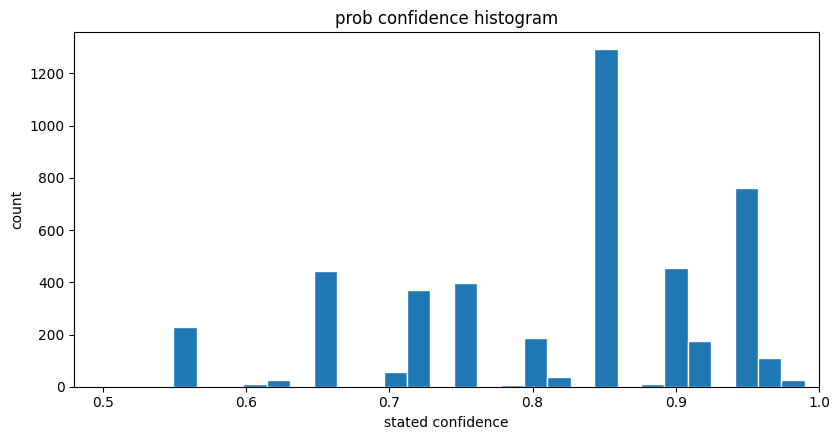

In [7]:
calib.plot_histograms(metrics)

In [8]:
# the value-counts view shows the model's confidence-in-chosen-label distribution
# (which lives in [0.5, 1.0] by construction). to see the raw P(ironic) instead,
# reconstruct it via:  p = conf if pred == 1 else 1 - conf  on each row.
calib.value_counts(signals["prob"][0], scale=SCALE, label="prob")

prob: 20 unique stated confidence values
   50:     3
   55:   230
   60:    11
   62:    24
   65:   444
   70:    55
   72:   372
   75:   396
   78:     8
   80:   187
   82:    39
   85:  1293
   88:    11
   90:   456
   92:   174
   95:   762
   96:     2
   97:   107
   98:    26
   99:     1


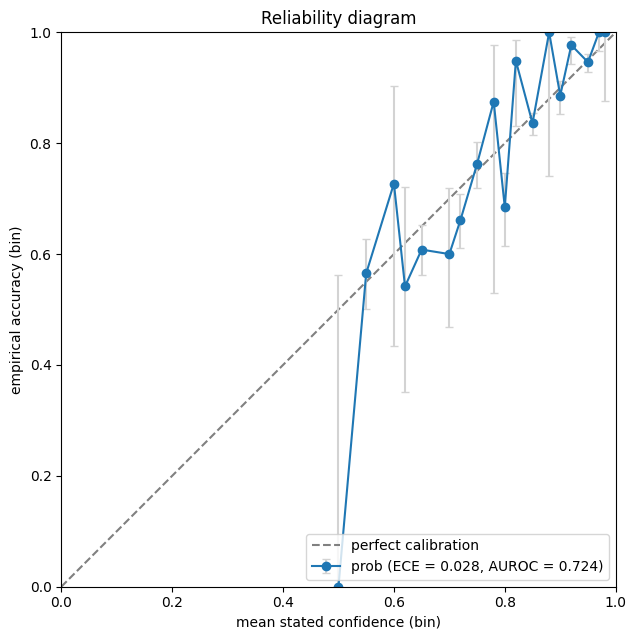

In [9]:
calib.plot_reliability(metrics)